# QC report


## Load raw data

In [2]:
  import json

  import numpy as np
  import pandas as pd
  import scanpy as sc
  import matplotlib.pyplot as plt
  import yaml

  with open("../config/config.yaml") as f:
      config = yaml.safe_load(f)
  qc_cfg = config["qc"]

  adata = sc.read_h5ad("../results/interim/raw.h5ad")
  adata

AnnData object with n_obs × n_vars = 126398 × 41332
    obs: 'sample_id', 'condition', 'donor'
    layers: None (.X)

## QC metrics: mito%, gene counts, complexity

In [3]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
print(f"mitochondrial genes found: {adata.var['mt'].sum()}")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe()

mitochondrial genes found: 11


,n_genes_by_counts,total_counts,pct_counts_mt
count,126398.000000,126398.000000,126398.000000
mean,519.990569,1402.967773,0.974124
std,1154.174116,3794.874512,1.731282
min,1.000000,1.000000,0.000000
25%,35.000000,67.000000,0.000000
50%,46.000000,111.000000,0.229885
75%,163.000000,525.000000,1.408451
max,10889.000000,101932.000000,53.638153


## Distributions before filtering, and why the thresholds were chosen

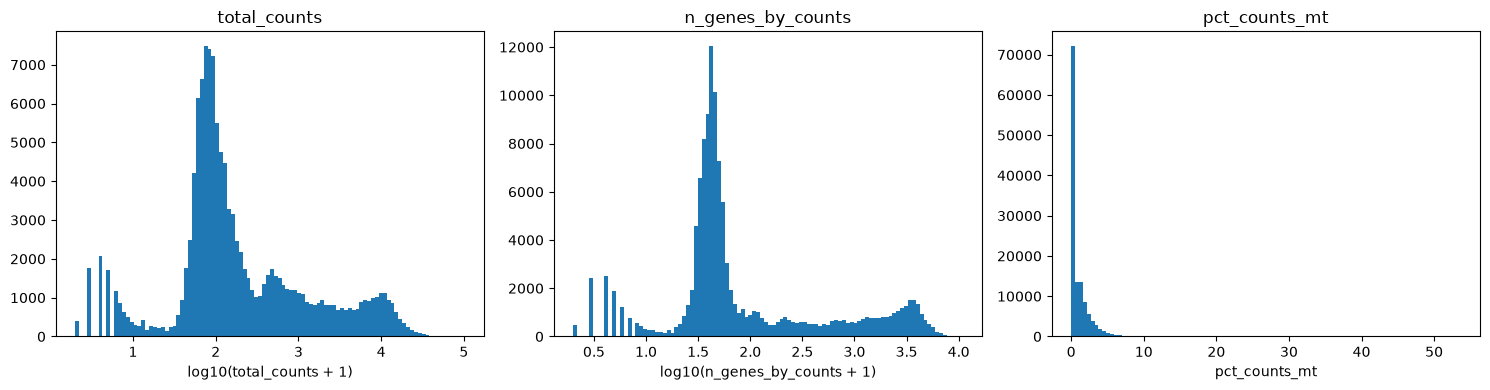

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(np.log10(adata.obs["total_counts"] + 1), bins=100)
axes[0].set_xlabel("log10(total_counts + 1)")
axes[0].set_title("total_counts")

axes[1].hist(np.log10(adata.obs["n_genes_by_counts"] + 1), bins=100)
axes[1].set_xlabel("log10(n_genes_by_counts + 1)")
axes[1].set_title("n_genes_by_counts")

axes[2].hist(adata.obs["pct_counts_mt"], bins=100)
axes[2].set_xlabel("pct_counts_mt")
axes[2].set_title("pct_counts_mt")

plt.tight_layout()
plt.savefig("../results/figures/qc_distributions.png")
plt.show()

## Filtering: cells and genes, with counts dropped at each step

to separate real nuclei from empty droplets, i plotted per-barcode UMI/gene counts on a log scale. two overlapping populations show up - a large empty-dropleat peak at low count and broader shoulder of real nuclei at higher counts. Valley between them sits at 80-150 genes. Btw mito filter did not seems to have huge impact which sort of makes sense for snRNA-seq data.


In [5]:
n_cells_before = adata.n_obs
sc.pp.filter_cells(adata, min_genes=qc_cfg["min_genes_per_cell"])
print(f"min_genes_per_cell={qc_cfg['min_genes_per_cell']}: {n_cells_before} -> {adata.n_obs} "
      f"(dropped {n_cells_before - adata.n_obs})")

n_cells_before = adata.n_obs
adata = adata[adata.obs["pct_counts_mt"] < qc_cfg["max_pct_mito"]].copy()
print(f"max_pct_mito={qc_cfg['max_pct_mito']}: {n_cells_before} -> {adata.n_obs} "
      f"(dropped {n_cells_before - adata.n_obs})")

n_genes_before = adata.n_vars
sc.pp.filter_genes(adata, min_cells=qc_cfg["min_cells_per_gene"])
print(f"min_cells_per_gene={qc_cfg['min_cells_per_gene']}: {n_genes_before} -> {adata.n_vars} "
      f"(dropped {n_genes_before - adata.n_vars})")

min_genes_per_cell=200: 126398 -> 30274 (dropped 96124)
max_pct_mito=20: 30274 -> 30267 (dropped 7)
min_cells_per_gene=3: 41332 -> 37204 (dropped 4128)


## Doublet detection (Scrublet)
Doublets are barcodes where two cells or nucleis are sequences as one. Scrublet simulates synthetic doublets (calculation takes time), projects them with real cells into shared PCA space and scores each real cell by proximity to the simulated-doublet cloud. As a fallback one can use configured expected rate of 6 percent and called the top scoring 6% of cells doublets by quantile instead.

Scrublet's automatic threshold: 0.557
max observed doublet_score: 0.447


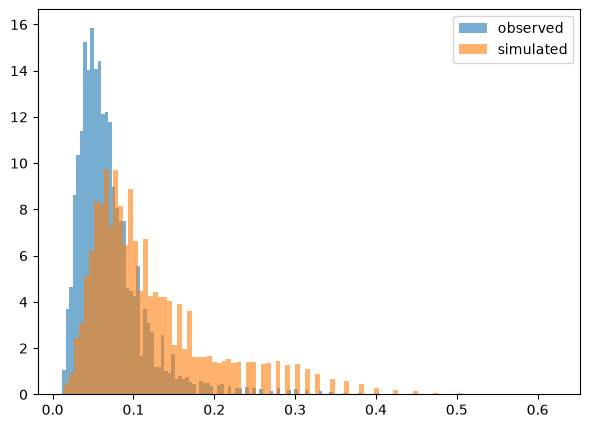

In [6]:
adata_hvg = adata.copy()
sc.pp.highly_variable_genes(adata_hvg, n_top_genes=2000, flavor="seurat_v3")
adata_subset = adata_hvg[:, adata_hvg.var["highly_variable"]].copy()

sc.pp.scrublet(adata_subset, expected_doublet_rate=qc_cfg["expected_doublet_rate"])
adata.obs["doublet_score"] = adata_subset.obs["doublet_score"]

print(f"Scrublet's automatic threshold: {adata_subset.uns['scrublet']['threshold']:.3f}")
print(f"max observed doublet_score: {adata.obs['doublet_score'].max():.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(adata_subset.obs["doublet_score"], bins=100, alpha=0.6, label="observed", density=True)
ax.hist(adata_subset.uns["scrublet"]["doublet_scores_sim"], bins=100, alpha=0.6, label="simulated", density=True)
ax.legend()
plt.savefig("../results/figures/doublet_scores_sim_vs_observed.png")
plt.show()


In [7]:
threshold = adata.obs["doublet_score"].quantile(1 - qc_cfg["expected_doublet_rate"])
adata.obs["predicted_doublet"] = adata.obs["doublet_score"] >= threshold
print(f"quantile-based threshold: {threshold:.4f}, doublet rate: {adata.obs['predicted_doublet'].mean():.4f}")

n_before = adata.n_obs
adata = adata[~adata.obs["predicted_doublet"]].copy()
print(f"doublets dropped: {n_before} -> {adata.n_obs} (dropped {n_before - adata.n_obs})")

quantile-based threshold: 0.1371, doublet rate: 0.0647
doublets dropped: 30267 -> 28310 (dropped 1957)


## Summary: before/after counts, and provenance

In [8]:
print(f"final QC'd shape (this notebook's walkthrough): {adata.n_obs} cells x {adata.n_vars} genes")

pipeline_output = sc.read_h5ad("../results/interim/qc_filtered.h5ad")
print(f"pipeline's qc_filtered.h5ad: {pipeline_output.n_obs} cells x {pipeline_output.n_vars} genes")

json.loads(pipeline_output.uns["provenance"])

final QC'd shape (this notebook's walkthrough): 28310 cells x 37204 genes
pipeline's qc_filtered.h5ad: 28310 cells x 37204 genes


[{'step': 'qc',
  'pipeline_version': '0.1.0',
  'input_hash': 'd6aab1be5c86ee57f74e85a2be283210633acb1e969c9871ca78d10b035071ea',
  'timestamp': '2026-08-22T11:23:29.034812+00:00',
  'params': {'min_genes_per_cell': 200,
   'max_pct_mito': 20,
   'min_cells_per_gene': 3,
   'expected_doublet_rate': 0.06}}]